In [2]:
!pip install -e ./wfcrl-env

Defaulting to user installation because normal site-packages is not writeable
ERROR: File "setup.py" not found. Directory cannot be installed in editable mode: /users/4/rozan012/weather-vein/wfcrl-env
(A "pyproject.toml" file was found, but editable mode currently requires a setup.py based build.)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from wfcrl.rewards import StepPercentage
from wfcrl import environments as envs

sns.set_theme(style="whitegrid")

In [4]:
envs.data_cases.named_cases_dictionary.keys()

dict_keys(['Turb_TCRWP_', 'Turb3_Row1_', 'Turb6_Row2_', 'Turb16_Row5_', 'Turb32_Row5_', 'Ablaincourt_', 'HornsRev1_', 'HornsRev2_', 'Ormonde_', 'WMR_'])

In [3]:
envs.data_cases.floris_wmr

Wind farm simulation on Floris: 35 turbines - 100 timesteps
xcoords: [3378.3280896, 4347.000730399999, 5287.63824580002, 6245.1108866000095, 7196.42677700001, 8167.2210428, 3900.5954734, 4871.9464891999805, 5812.30562940001, 7721.61578559999, 8675.33167620002, 4425.78448199999, 5359.743622199991, 8214.491293600011, 9173.842309599999, 4924.781614799999, 5879.854255599999, 8733.28030220001, 9684.317817600011, 5464.9273735999905, 6427.2000144, 7378.794280199991, 9287.30443639999, 10234.620326, 5977.03800720001, 6904.0755223999895, 7895.70491359999, 9810.09344499998, 10763.809336, 6505.9486406, 7463.42128139998, 8404.5804216, 9378.609812800001, 10340.325703999999, 11288.47672]
ycoords: [6514.8637897997005, 7132.538836799939, 7762.2424016000205, 8388.74596620019, 9021.40187620011, 9628.95309560009, 5724.1606004003, 6347.21651039973, 6971.5962475998, 8218.97485920013, 8849.23076920029, 4993.07617259966, 5589.1227016002795, 7463.8048780002, 8094.06078799964, 4167.17298319965, 4786.17185739981

In [2]:
envs.list_envs()

['Turb_TCRWP_Fastfarm',
 'Turb_TCRWP_Floris',
 'Turb3_Row1_Fastfarm',
 'Turb3_Row1_Floris',
 'Turb6_Row2_Fastfarm',
 'Turb6_Row2_Floris',
 'Turb16_Row5_Fastfarm',
 'Turb16_Row5_Floris',
 'Turb32_Row5_Fastfarm',
 'Turb32_Row5_Floris',
 'Ablaincourt_Fastfarm',
 'Ablaincourt_Floris',
 'HornsRev1_Fastfarm',
 'HornsRev1_Floris',
 'HornsRev2_Fastfarm',
 'HornsRev2_Floris',
 'Ormonde_Fastfarm',
 'Ormonde_Floris',
 'WMR_Fastfarm',
 'WMR_Floris',
 'Turb1_Row1_Fastfarm',
 'Turb1_Row1_Floris',
 'Turb2_Row1_Fastfarm',
 'Turb2_Row1_Floris',
 'Turb3_Row1_Fastfarm',
 'Turb3_Row1_Floris',
 'Turb4_Row1_Fastfarm',
 'Turb4_Row1_Floris',
 'Turb5_Row1_Fastfarm',
 'Turb5_Row1_Floris',
 'Turb6_Row1_Fastfarm',
 'Turb6_Row1_Floris',
 'Turb7_Row1_Fastfarm',
 'Turb7_Row1_Floris',
 'Turb8_Row1_Fastfarm',
 'Turb8_Row1_Floris',
 'Turb9_Row1_Fastfarm',
 'Turb9_Row1_Floris',
 'Turb10_Row1_Fastfarm',
 'Turb10_Row1_Floris',
 'Turb11_Row1_Fastfarm',
 'Turb11_Row1_Floris',
 'Turb12_Row1_Fastfarm',
 'Turb12_Row1_Floris',


In [33]:
env = envs.make("Turb3_Row1_Floris", max_num_steps=70)

In [26]:
print(env.num_turbines)
print(env.action_space)
print(env.observation_space)

3
Dict('yaw': Box(-5.0, 5.0, (3,), float32))
Dict('yaw': Box(-40.0, 40.0, (3,), float32), 'freewind_measurements': Box([3. 0.], [ 28. 360.], (2,), float32), 'wind_speed': Box(3.0, 28.0, (3,), float32), 'wind_direction': Box(0.0, 360.0, (3,), float32))


In [27]:
observation = env.reset()
print(observation)

OrderedDict({'yaw': array([0., 0., 0.]), 'freewind_measurements': array([  7.12361443, 264.25103318]), 'wind_speed': array([7.10013589, 5.47479463, 5.52269261]), 'wind_direction': array([264.52391008, 264.79444654, 264.86353967])})


In [28]:
def step_policy(i):
    # Change yaw by a random int every 5th iteration
    joint_action = {"yaw": np.zeros((env.num_turbines))}
    if i % 5 == 0:
        joint_action["yaw"][int(i/5  % env.num_turbines)] = np.random.randint(-5,5)
    return joint_action

In [29]:
observation = env.reset()
r, i = 0, 0
done = False
while not done:
    joint_action = step_policy(i)
    observation, reward, termination, truncation, info = env.step(joint_action)
    r += reward
    i += 1
    done = termination or truncation
print(f"Total reward = {r}")

Total reward = [114.89088342]


In [43]:
columns = [f"T{i+1}" for i in range(env.num_turbines)]
yaws = pd.DataFrame(np.c_[[h["yaw"] for h in env.history["observation"]]], columns=columns)
powers = pd.DataFrame(np.c_[[h for h in env.history["power"]]], columns=columns)
yaws

,T1,T2,T3,T4,T5,T6,T7
0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
64,2.0,1.0,-4.0,-6.0,-5.0,-7.0,-5.0
65,2.0,1.0,-4.0,-6.0,-5.0,-7.0,-3.0
66,2.0,1.0,-4.0,-6.0,-5.0,-7.0,-3.0
67,2.0,1.0,-4.0,-6.0,-5.0,-7.0,-3.0


[Text(0, 0.5, 'Power (MW)'), Text(0.5, 0, 'Iterations')]

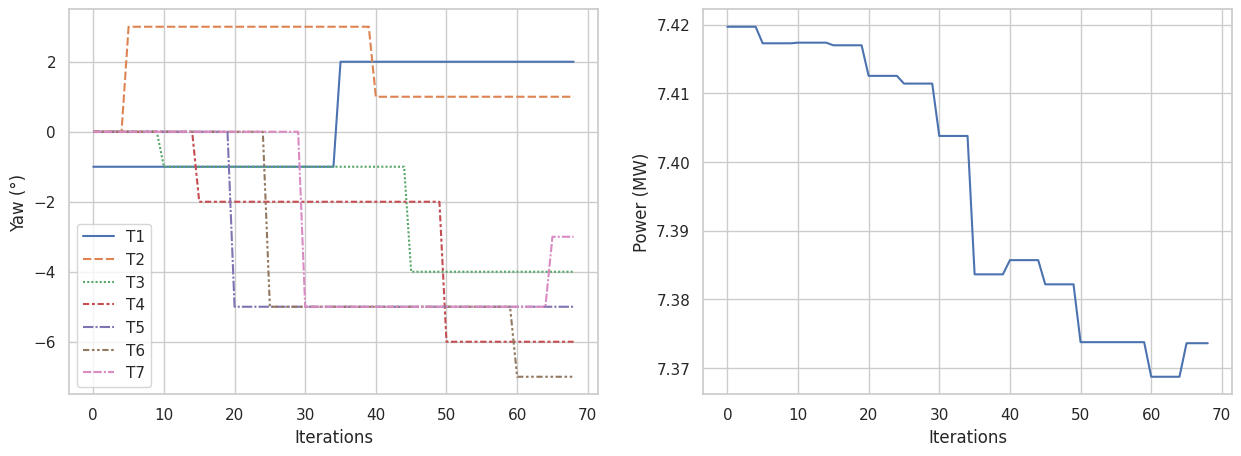

In [44]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
ax0 = sns.lineplot(yaws, ax=ax[0])
ax1 = sns.lineplot(powers.sum(1), ax=ax[1])
ax0.set(ylabel="Yaw (°)", xlabel="Iterations")
ax1.set(ylabel="Power (MW)", xlabel="Iterations")